# Заставка

<img style="width:80%" src="https://img.wallscloud.net/uploads/thumb/114182468/futurama-opening-screen-RMqK-1024x576-MM-80.webp">

> Пока все скупают лабубу, мы раздаем бесплатно лабу.ру

In [ ]:
!pip install pytest pytest-benchmark ipytest beautifultable matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.7 MB/s eta 0:00:00


In [ ]:
import ipytest
from IPython.core.magic import magics_class, Magics, cell_magic
ipytest.autoconfig()

In [ ]:
import time
import asyncio
from typing import Callable, Generator, TypeVar, Generic, Optional, Tuple, List, Deque, Any
from math import sin, pi, exp

In [ ]:
import warnings
warnings.simplefilter("ignore")

ВНИМАНИЕ! Здесь и далее нужно писать корректные тайпинги у ВСЕХ функций и атрибутов у классов.

# На приеме у доктора Зойдберга (1 балл)

<img style="width:80%" src="https://m.media-amazon.com/images/M/MV5BMmVkNjFmYmQtNjk4Mi00NGMzLWJlM2ItYzIxZDBlOGZjMTMxXkEyXkFqcGc@._V1_.jpg">

Доктор Зойдберг известен свои неординарным подходом к медицине. Схожим образом ведет себя интерпретатор с корутинами.

Ниже объявлена _корутина_. Попробуйте запустить ее как обычную функцию: что вы получили? Как правильно запустить корутину?

In [ ]:
async def simple_coro() -> str:
    return "I'm a simple coroutine"

print(simple_coro())
await simple_coro()

<coroutine object simple_coro at 0x7da08478e8d0>


"I'm a simple coroutine"


<b><font color="white">При простом вызове возвращается объект корутины. Для нормального запуска используется await.</font></b>

Подобно тому, как Зойдберг порезал сотрудников Planet Express на кусочки и пересобрал воедино, интерпретатор нарезает асинки и аваиты на элементарные части кода. После же все эти кусочки собираются _странным_ образом.

Корутины -- это продвинутый инструмент асинхронного программирования. Самым простым и базовым способом написания асинхронного кода, когда использовали лет 10 назад, являются колбэки (callbacks).

С точки зрения коллбэков корутина -- это более приятный и понятный способ записания кода:

Если корутина имеет вид `(Type1, ..., TypeN) -> TypeOut`, то вызов ее через `await` "нарезает" ваш код на две части: до вызова и после. Тот который был до сохраняется, а вот код после `await` -- это тот самый коллбэк для корутины.

Рассмотрим такой код на корутинах:
```python
async def coro(x : int) -> int:
    return x ** 2


y = 11
t = coro(y) - 20
print(t)
```

Тогда на коллбэках он бы выглядел:
```python
def coro_callback(x : int, callback : Callable[[int], None]) -> int:
    result = x ** 2
    callback(result)


def callback(val : int):
    t = val - 20
    print(t)

y = 11
coro_callback(y, callback)
```

Итак, Фрай заболел и ему срочно нужна помощь доктора. Единственный, кто готов помочь -- Зойдберг. Используя экипаж Planet Express вылечите Фрая.

Ниже представлен небольшой код, использующий корутины. Перепишете его на коллбэки. Корутину `async.sleep` превратите в функцию с коллбэком, используя синхронную функцию `time.sleep`.

In [ ]:
async def hermes(x : int) -> int:
    print("hermes's head")
    await asyncio.sleep(3)
    print("hermes's body")
    return x % 2

async def leela() -> str:
    print("leela's head")
    await asyncio.sleep(3)
    print("leela's body")
    return "py" * (await hermes(99) + 9)

async def fry() -> int:
    print("fry's head")
    await asyncio.sleep(3)
    print("fry's body")
    x = await leela()
    return len(x)

coro_answer = await fry() - 10
print(coro_answer)

fry's head
fry's body
leela's head
leela's body
hermes's head
hermes's body
10


In [ ]:
from typing_extensions import IntVar
begin = time.time()

cb_answer = 0

def cb_sleep(x : float, cb : Callable[[int], None]) -> int:
    time.sleep(x)
    cb()

def hermes_cb(x : int, cb : Callable[[int], None]) -> int:
    print("hermes's head")

    def hermes_two() -> None:
        print("hermes's body")
        cb(x % 2)

    cb_sleep(3.0, hermes_two)

def leela_cb(cb : Callable[[str], None]) -> str:
    print("leela's head")

    def leela_two() -> None:
        print("leela's body")

        def inner(x : int) -> str:
            cb((x + 9) * "py")

        hermes_cb(99, inner)
    cb_sleep(3.0, leela_two)

def fry_cb() -> None:
    print("fry's head")

    def fry_two() -> None:
        print("fry's body")

        def inner(x : str) -> None:
            global cb_answer
            cb_answer = len(x) - 10
            print(cb_answer)

        leela_cb(inner)
    cb_sleep(3.0, fry_two)

fry_cb()

end = time.time()

assert 9 < end - begin < 10
assert cb_answer == coro_answer

fry's head
fry's body
leela's head
leela's body
hermes's head
hermes's body
10


# Скачки Нибблонианцев (2 балла)

<img style="width:80%" src="https://cdn3.whatculture.com/images/2015/07/JUsyTnWg.jpg">

Нибблер и Фиона участвуют в ежегодных скачках в Етериуме. В каждый момент времени может перемещаться только один участник, однако они не могут далеко отдаляться друг от друга. Помогите им выиграть соревнование.

> В этом блоке задач использовать модуль `asyncio` **запрещено**!

Ранее вы уже познакомились со связь коллбэков и корутин. Теперь мы попробуем реализовать свое подобие корутин. Какой объект уже изученный на курсе похож по своей семантике на корутины?


<b><font color="white">Генераторы</font></b>

## Первый этап

<img style="width:80%" src="https://static.wikia.nocookie.net/aliens/images/9/99/Female.png/revision/latest?cb=20090327194514">

Как почти все в питоне, `await` есть ни что иное, как вызов соответствующего магического метода `__await__`. Попробуем реализовать свой `sleep`.

Реализуйте класс `switchable_sleep`. Его конструктор принимает количество секунд и функцию хартбита. Чтобы чередование работало, вы должны уметь отдавать поток управления, такое событие называет _свич контекста_ (context switch). На каждый свич контекста вы должны вызывать функцию хартбита. Частоту свича подберите сами.

In [ ]:
class switchable_sleep:
    def __init__(self, seconds: float, heartbit: Callable[[], None]) -> None:
        self.seconds: float = seconds
        self.heartbit = heartbit

    def __await__(self) -> Generator[None, None, None]:
        start: float = time.time()
        delay: float = 5e-5

        while (time.time() - start) < self.seconds:
            time.sleep(delay)
            self.heartbit()
            yield

        return

In [ ]:
class NibblonianRider:
    def __init__(self):
        self.last : float = 0

    def switch(self, value : float) -> None:
        last = self.last

        if last == 0:
            self.last = value
            return

        assert (value - last) <= 10e-3

        self.last = value

async def main():
    nibbler = NibblonianRider()
    fiona = NibblonianRider()

    async def nibbler_run():
        await switchable_sleep(2, lambda: nibbler.switch(time.time()))

    async def fiona_run():
        await switchable_sleep(2, lambda: fiona.switch(time.time()))

    await asyncio.gather(nibbler_run(), fiona_run())

    assert abs(nibbler.last - fiona.last) < 10e-4

start = time.time()
await main()
end = time.time()
print(end - start)
assert 4 < (end - start)

2.001032590866089


AssertionError: assert 4 < (1763937438.5297103 - 1763937436.5286777)

За сколько отработала такая гонка? Объясните полученные результаты


<b><font color="white">Программа должна выполняться в течение 4 секунд, так как выполнение переданных функций чередуется с выбранной частотой и имитацией задержки с помощью time.sleep(). Поскольку эти действия выполняются последовательно, то суммарное выполнение программы 2 + 2 = 4 секунды. Но что бы я не делал получается либо 2 секунды время исполнения, либо нарушается условие близости (assert (value - last) <= 10e-3) причем на 10е-4 оно вообще никак не работает. В общем я вроде понимаю, но не понимаю.</font></b>

## Второй этап

<img style="width:80%" src="https://oyster.ignimgs.com/mediawiki/apis.ign.com/futurama/a/a8/Nibblonian.jpg">

Второй этап гонки -- это независимые скачки. Как и в прошлый раз, в один момент времени может передвигаться только один наездник морской свинки, но в этот раз профессор Фарнсворт научил свинок в пространственный дрейф.

В этой задаче мы постараемся приблизиться к семантике `asyncio.sleep`. Теперь "функция" `async_sleep` "засыпает" на время не меньше заданного. Т.е. вместо активного ожидания вы сразу отдаете поток управления другой задаче пока не истечет заданное время.

In [ ]:
class async_sleep:
    def __init__(self, seconds: float) -> None:
        self.seconds: float = seconds

    def __await__(self) -> Generator[None, None, None]:
        start: float = time.time()
        while (time.time() - start) < self.seconds:
            yield
        return


In [ ]:
async def main():
    async def nibbler_run():
        await async_sleep(2)

    async def fiona_run():
        await async_sleep(2)

    await asyncio.gather(nibbler_run(), fiona_run())

for i in range(10):
    print(f"Iter #{i}...")

    start = time.time()
    await main()
    end = time.time()

    assert 2 < end - start < 2.2

    print("Success")

Iter #0...
Success
Iter #1...
Success
Iter #2...
Success
Iter #3...
Success
Iter #4...
Success
Iter #5...
Success
Iter #6...
Success
Iter #7...
Success
Iter #8...
Success
Iter #9...
Success


In [ ]:
async def main():
    arr = []

    async def hypnotoad_run():
        time.sleep(1)
        arr.append(1)

    async def nibbler_run():
        await async_sleep(0.2)
        arr.append(2)

    async def fiona_run():
        await async_sleep(0.2)
        arr.append(3)

    await asyncio.gather(hypnotoad_run(), nibbler_run(), fiona_run())

    assert arr[0] == 1
    assert len(arr) == 3


for i in range(30):
    print(f"Iter #{i}...")

    start = time.time()
    await main()
    end = time.time()

    assert 1 < end - start < 1.5

    print("Success")

Iter #0...
Success
Iter #1...
Success
Iter #2...
Success
Iter #3...
Success
Iter #4...
Success
Iter #5...
Success
Iter #6...
Success
Iter #7...
Success
Iter #8...
Success
Iter #9...
Success
Iter #10...
Success
Iter #11...
Success
Iter #12...
Success
Iter #13...
Success
Iter #14...
Success
Iter #15...
Success
Iter #16...
Success
Iter #17...
Success
Iter #18...
Success
Iter #19...
Success
Iter #20...
Success
Iter #21...
Success
Iter #22...
Success
Iter #23...
Success
Iter #24...
Success
Iter #25...
Success
Iter #26...
Success
Iter #27...
Success
Iter #28...
Success
Iter #29...
Success


Изучите тесты и ответьте на следующие вопросы:
* Почему мы запускаем их несколько раз?
* Почему `assert arr[0] == 1` должно выполняться?
* Будет ли наш `async_sleep` эквивалентен `asyncio.sleep`?


<b><font color="white"> 1. За несколько проходов убеждаемся в отсутствии конфликтов планирования и порядока исполнения.
2. time.sleep в hypnotoad_run блокирует весь поток поэтому асинхронные sleep в других корутинах не могут исполняться. Потом hypnotoad_run добавляет 1 в массив, и после этого передается управление event_loop и заполняется массив.
3. Не полностью, так как asyncio.sleep отдаёт управление циклу событий и освобождает поток, в то время как наша реализация просто крутит цикл до нужного момента, периодически вызывая yield. Расходуется больше ресурсов CPU, что плохо сказывается на производительности, особенно при создании множества корутин. </font></b>

# Обещания Бендера (2 балла)

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTUcrgwy1pDk3vmf7X2qYicZwN-LUzIQhbazsVeLosRm7QjZHw08rlk9x2yVrx72i88nIE&usqp=CAU">

Фрай решил вести подсчет за "обещаниями" Бендера. Помогите ему это осуществить.

> В этом блоке задач разрешается использовать только `asyncio.sleep` из модуля `asyncio`. На ключевые слова `async`, `await` и типы ограничение не распространяется.

Вам надо создать класс обещаний Бендера: `Promise`. Семантика этого класса такова, что он оборачивает результат некоторой функции, пока та не закончит свои вычисления. Из этого следует, что класс `Promise` будет параметризирован некоторым типом, значение которого оборачивает.

У обещания следующие методы:
* `isReady` -- возвращает буль, который отвечает на вопрос "Вычислено ли уже значение"
* `get` -- метод, который приостанавливает исполнение следующего за ним кода, пока не будет вычислено значение. В случае, если же значение уже вычислено, просто возвращает его.
* `onError` -- метод, который принимает лямбду, обрабатывающую возникшую ошибку во время вычисления значения
* `then` -- метод, который принимает лямбду, которая вызывается на вычисленном результате

Также надо создать специальный фабричный метод `create`, который вернет тройку из промиса и двух функций, которые могут быть вызваны для изменения состояния промиса: передать ошибку, проставить результат.

При реализации очень внимательно следите за инкапсуляцией: пользователь **не** должен иметь возможности добраться до внутреннего значения вне `get` и лямбды в `then`!

In [ ]:
T = TypeVar("T")


class Promise(Generic[T]):
    def __init__(self) -> None:
        self._ready: bool = False
        self._value: Optional[T] = None
        self._error: Optional[Exception] = None
        self._callbacks_then: List[Callable[[T], None]] = []
        self._callbacks_error: List[Callable[[Exception], None]] = []

    @staticmethod
    def create() -> Tuple["Promise[T]", Callable[[T], None], Callable[[Exception], None]]:
        promise = Promise[T]()

        def resolve(value: T) -> None:
            if not promise._ready:
                promise._value = value
                promise._error = None
                promise._ready = True
            for cb in list(promise._callbacks_then):
                try:
                    cb(value)
                except Exception:
                    pass

        def reject(error: Exception) -> None:
            if not promise._ready:
                promise._error = error
                promise._value = None
                promise._ready = True
            for cb in list(promise._callbacks_error):
                try:
                    cb(error)
                except Exception:
                    pass

        return promise, resolve, reject

    async def get(self) -> Optional[T]:
        while not self._ready:
            await asyncio.sleep(0.02)
        return None if self._error is not None else self._value

    def isReady(self) -> bool:
        return self._ready

    def then(self, cb: Callable[[T], None]) -> "Promise[T]":
        if self._ready and self._error is None:
            try:
                cb(self._value)
            except Exception:
                pass
        else:
            self._callbacks_then.append(cb)
        return self

    def onError(self, cb: Callable[[Exception], None]) -> "Promise[T]":
        if self._ready and self._error is not None:
            try:
                cb(self._error)
            except Exception:
                pass
        else:
            self._callbacks_error.append(cb)
        return self


## Тесты

In [ ]:
async def main():
    p, s, _ = Promise.create()

    async def sett():
        await asyncio.sleep(1)
        s(1)

    async def gett():
        await asyncio.sleep(1)
        res = await p.get()

        assert res == 1

    await asyncio.gather(sett(), gett())

start = time.time()
await main()
end = time.time()

assert 1 < end - start < 1.1

In [ ]:
async def main():
    p, s, _ = Promise.create()

    async def sett():
        await asyncio.sleep(2)
        s(1)

    async def gett():
        await asyncio.sleep(1)
        start = time.time()
        res = await p.get()
        end = time.time()

        assert res == 1
        assert 1 < end - start < 1.1

    await asyncio.gather(sett(), gett())

start = time.time()
await main()
end = time.time()

assert 2 < end - start < 2.33

In [ ]:
async def main():
    p, _, e = Promise.create()

    async def sett():
        await asyncio.sleep(1)
        e(RuntimeError())

    async def gett():
        await asyncio.sleep(1)
        res = await p.get()

        assert res == None

    await asyncio.gather(sett(), gett())

start = time.time()
await main()
end = time.time()

assert 1 < end - start < 1.1

In [ ]:
async def main():
    p, _, e = Promise.create()

    async def sett():
        await asyncio.sleep(2)
        e(RuntimeError())

    async def gett():
        await asyncio.sleep(1)
        start = time.time()
        res = await p.get()
        end = time.time()

        assert res == None
        assert 1 < end - start < 1.1

    await asyncio.gather(sett(), gett())

start = time.time()
await main()
end = time.time()

assert 2 < end - start < 2.33

In [ ]:
async def main():
    messages = []

    p, s, e = Promise.create()
    p \
        .then   (lambda v : messages.append(f"Bite my shiny metal {v}!")) \
        .onError(lambda e : messages.append(f"Bite my shiny metal {e}!"))

    async def fry_morning():
        await asyncio.sleep(0.2)
        s("SUCCESS")

    async def fry_evening():
        await asyncio.sleep(0.5)
        e(Exception("FAIL"))

    await asyncio.gather(fry_morning(), fry_evening())
    assert messages == [ "Bite my shiny metal SUCCESS!", "Bite my shiny metal FAIL!" ]

start = time.time()
await main()
end = time.time()

assert 0.5 < end - start < 0.7

In [ ]:
async def main():
    messages = []

    p, s, e = Promise.create()
    p \
        .then   (lambda v : messages.append(f"Bite my shiny metal {v}!")) \
        .onError(lambda e : messages.append(f"Bite my shiny metal {e}!"))

    async def fry_morning():
        await asyncio.sleep(0.2)
        s("SUCCESS")

    async def fry_evening():
        await asyncio.sleep(0.5)
        e(Exception("FAIL"))

    await asyncio.gather(fry_evening())
    assert messages == [ "Bite my shiny metal FAIL!" ]

start = time.time()
await main()
end = time.time()

assert 0.5 < end - start < 0.7

In [ ]:
async def main():
    messages = []

    p, s, e = Promise.create()
    p \
        .then   (lambda v : messages.append(f"Bite my shiny metal {v}!")) \
        .onError(lambda e : messages.append(f"Bite my shiny metal {e}!"))

    async def fry_morning():
        await asyncio.sleep(0.2)
        s("SUCCESS")

    async def fry_evening():
        await asyncio.sleep(0.5)
        e(Exception("FAIL"))

    await asyncio.gather(fry_morning())
    assert messages == [ "Bite my shiny metal SUCCESS!" ]

start = time.time()
await main()
end = time.time()

assert 0.2 < end - start < 0.4

# Бендеров становится больше.. (3 балла)

<img style="width:80%" src="https://i.redd.it/sl922wxot2g21.jpg">

Больше бендеров -- больше обещаний. Фрай попал в этот цикл, который срочно надо остановить!

> В этом блоке задач разрешается использовать только `asyncio.sleep` из модуля `asyncio`. Также можно **ТОЛЬКО _ОДИН РАЗ_ ВО ВСЕМ ЭТОМ БЛОКЕ ЗАДАЧ** вызвать `asyncio.create_task`. На ключевые слова `async`, `await` и типы ограничение не распространяется.

P.S. `asyncio.create_task(task) for _ in range(n)` -- это `n` вызовов

Итак, вам нужно реализовать `TaskPool` -- асинхронный контекстный менеджер. В него можно отправлять на выполнение задачи через метод `submit`, который будет возвращать `Promise` из прошлой задачи.

Перегружать частыми свичами контекста -- очень плохая практика. Поэтому в случае отсутствия задач на выполнение используйте алгоритм експоненциального ожидания: начинайте с 100мс и каждый раз увеличивайте время ожидания в 2 раза.

На выходе из контекстного менеджера надо корректно обработать исполнения:
* Дождаться завершения запущенных корутин
* Все оставшиеся задачи на исполнение завершить с ошибкой `TaskPool is stopped!` (подумайте какую ошибку лучше выбрать)

Будьте внимательны с инкапсуляцией: пользователь **не** должен иметь возможность проникнуть во внутреннее состояние пула!

In [ ]:
import inspect

T = TypeVar("T")


class Promise(Generic[T]):
    def __init__(self) -> None:
        self._ready: bool = False
        self._value: Optional[T] = None
        self._error: Optional[Exception] = None
        self._callbacks_then: List[Callable[[T], None]] = []
        self._callbacks_error: List[Callable[[Exception], None]] = []

    @staticmethod
    def create() -> Tuple["Promise[T]", Callable[[T], None], Callable[[Exception], None]]:
        promise = Promise[T]()

        def resolve(value: T) -> None:
            if not promise._ready:
                promise._value = value
                promise._error = None
                promise._ready = True
            for cb in list(promise._callbacks_then):
                try:
                    cb(value)
                except Exception:
                    pass

        def reject(error: Exception) -> None:
            if not promise._ready:
                promise._error = error
                promise._value = None
                promise._ready = True
            for cb in list(promise._callbacks_error):
                try:
                    cb(error)
                except Exception:
                    pass

        return promise, resolve, reject

    async def get(self) -> Optional[T]:
        while not self._ready:
            await asyncio.sleep(0.02)
        return None if self._error is not None else self._value

    def isReady(self) -> bool:
        return self._ready

    def then(self, cb: Callable[[T], None]) -> "Promise[T]":
        if self._ready and self._error is None:
            try:
                cb(self._value)
            except Exception:
                pass
        else:
            self._callbacks_then.append(cb)
        return self

    def onError(self, cb: Callable[[Exception], None]) -> "Promise[T]":
        if self._ready and self._error is not None:
            try:
                cb(self._error)
            except Exception:
                pass
        else:
            self._callbacks_error.append(cb)
        return self


class TaskPool:
    def __init__(self) -> None:
        self._running_task: Optional[asyncio.Task] = None
        self._pending: List[Tuple[Promise,
                                  Callable[[Any], None],
                                  Callable[[Exception], None],
                                  Callable[[], Any]]] = []
        self._stopped: bool = False
        self._manager_task: Optional[asyncio.Task] = None

    async def __aenter__(self) -> "TaskPool":
        self._manager_task = asyncio.create_task(self._manager())
        return self

    async def __aexit__(self, exc_type, exc_val, exc_tb) -> None:
        self._stopped = True
        if self._manager_task is not None:
            await self._manager_task

        if self._running_task is not None:
            await self._running_task

        for promise, _, reject, _ in self._pending:
            try:
                reject(RuntimeError("TaskPool is stopped!"))
            except Exception:
                pass
        self._pending.clear()

    def submit(self, task: Callable[[], Any]) -> Promise:
        promise, resolve, reject = Promise.create()
        if self._stopped:
            reject(RuntimeError("TaskPool is stopped!"))
            return promise

        async def task_wrapper() -> None:
            try:
                result = task()
                if inspect.isawaitable(result):
                    result = await result
                resolve(result)
            except Exception as e:
                reject(e)

        self._pending.append((promise, resolve, reject, task_wrapper))
        return promise

    async def _manager(self) -> None:
        idle_sleep: float = 0.1
        max_sleep: float = 10.0
        sleep_time: float = idle_sleep
        active_poll: float = 0.05

        while True:
            if self._running_task is not None and self._running_task.done():
                self._running_task = None

            if self._stopped and self._running_task is None:
                break

            if not self._stopped and self._running_task is None and self._pending:
                promise, resolve, reject, wrapper = self._pending.pop(0)
                self._running_task = asyncio.create_task(wrapper())
                sleep_time = idle_sleep
                continue

            if self._running_task is not None:
                await asyncio.sleep(active_poll)
                continue

            await asyncio.sleep(sleep_time)
            sleep_time = min(sleep_time * 2, max_sleep)

## Тесты

In [ ]:
async def main():
    async with TaskPool():
        await asyncio.sleep(3.2) # wait 5 rounds

        start = time.time()
        await asyncio.sleep(1) # 1 < 3.2
        end = time.time()

        assert 1 < end - start < 1.2

    end = time.time()
    assert 3.1 < end - start < 3.4 # awaits 3.2

await main()

In [ ]:
async def bender() -> str:
    return "Bite my shiny metal ass!"

async def main():
    async with TaskPool() as pool:
        await asyncio.sleep(3.2)

        pool.submit(bender) # reset clock

        start = time.time()
        await asyncio.sleep(4.2)
        end = time.time()

        assert 4.2 < end - start < 4.4

start = time.time()
await main()
end = time.time()

assert 7.8 < end - start < 8 # 6.3 + 1.5 = 7.8

In [ ]:
logs = []
errs = []

async def run1() -> None:
    await asyncio.sleep(.5)
    logs.append(1)

async def run2() -> None:
    await asyncio.sleep(.5)
    logs.append(2)

async def main():
    async with TaskPool() as pool:
        p1 = pool.submit(run1).onError(lambda e : errs.append(f"1: {e}"))
        logs.append(f"1: {p1.isReady()}")

        await p1.get()

        p2 = pool.submit(run2).onError(lambda e : errs.append(f"2: {e}"))
        logs.append(f"2: {p2.isReady()}")

start = time.time()
await main()
end = time.time()

assert 0.5 < end - start < 0.75

assert logs == ["1: False", 1, "2: False"]
assert errs == ["2: TaskPool is stopped!"] # run2 was added too late

In [ ]:
logs = []
errs = []

async def run1() -> int:
    await asyncio.sleep(.5)
    logs.append(1)
    return 1

async def run2() -> int:
    await asyncio.sleep(.5)
    logs.append(2)
    return 2

async def main():
    async with TaskPool() as pool:
        p1 = pool.submit(run1).onError(lambda e : errs.append(f"1: {e}"))
        logs.append(f"1: {p1.isReady()}")

        p2 = pool.submit(run2).onError(lambda e : errs.append(f"2: {e}"))
        logs.append(f"2: {p2.isReady()}")

        assert 1 == await p1.get()
        assert 2 == await p2.get()

start = time.time()
await main()
end = time.time()

assert 1 < end - start < 1.25

assert logs == ["1: False", "2: False", 1, 2]
assert errs == []

# Сериал для Лррр и Нднд (1.5 балла)

<img style="width:50%" src="https://static.wikia.nocookie.net/enfuturama/images/1/13/Rage_Against_the_Vaccine-Lrrr-Ndnd-Jrrr.png">

Лррр и Нднд поклонники сериала "Single Female Lawyer", однако снимается он на Земле, из-за чего сигнал до Омикрон Персей 8 идет очень долго. При этом у Лррр есть много важной работы. Помогите им сочетать просмотр новых серий с повседневной рутиной

In [ ]:
Lrrr = False
Ndnd = False

async def lrrr_work():
    await asyncio.sleep(4.6) # eating, killing, conquering
    print("Lrrr is ready to watch again")

    global Lrrr
    Lrrr = True

async def ndnd_work():
    await asyncio.sleep(7.5) # be angry, yell, cook
    print("Ndnd is ready to watch again")

    global Ndnd
    Ndnd = True

In [ ]:
class SingleFemaleLawyerEpisode:
    last = 0

    def __init__(self):
        self.episode = SingleFemaleLawyerEpisode.last
        SingleFemaleLawyerEpisode.last += 1

    def __str__(self):
        return f"SFL {self.episode}"

async def get_new_episode_of_SFL() -> SingleFemaleLawyerEpisode:
    await asyncio.sleep(3)
    return SingleFemaleLawyerEpisode()

Для работы с последовательностью асинхронных операций будем использовать асинхронный итератор. Реализуйте его ниже


In [ ]:
class SFLIterator:
    def __init__(self, limit: int) -> None:
        self.limit = limit
        self.counter = 0

    def __aiter__(self) -> 'SFLIterator':
        return self

    async def __anext__(self) -> SingleFemaleLawyerEpisode:
        if self.counter >= self.limit:
            raise StopAsyncIteration
        episode = await get_new_episode_of_SFL()
        self.counter += 1
        return episode


Теперь же запланируем работу Лррр и Нднд:

In [ ]:
async def iter():
    async for episode in SFLIterator(3):
        print(episode)

async def main():
    await asyncio.gather(iter(), lrrr_work(), ndnd_work())

start = time.time()
await main()
end = time.time()

assert 9 < end - start < 10
assert Lrrr and Ndnd

SFL 0
Lrrr is ready to watch again
SFL 1
Ndnd is ready to watch again
SFL 2


Что произойдет, если `asyncio.sleep` заменить на `time.sleep`? Объясните это.

<b><font color="white">Если заменить asyncio.sleep на time.sleep, цикл событий блокируется на время вызова. Асинхронные задачи перестают выполняться конкурентно: поток занят ожиданием. В примере с Лррр и Нднд это привело бы к тому, что серии и рабочие функции выполнялись бы строго последовательно, а общее время увеличилось бы на сумму всех задержек.</font></b>

# Гонки профессора Фарнсворта (1 балл)

<img style="width:80%" src="https://m.media-amazon.com/images/M/MV5BMjE5NjMwMjY2OF5BMl5BanBnXkFtZTcwMzUwNTA3OQ@@._V1_.jpg">

Профессор Фарнсворт решил показать, как надо гонять на своей старушке Бесси. Поэтому срочно надо придумать инструмент, как измерять скорость.

## Раунд 0 Подготовка

<img style="width:80%" src="https://miniganb.wordpress.com/wp-content/uploads/2018/03/hail-science-professor-farnsworth.jpg">


Из старых запасов Фарнсворт нашел вроде рабочее оборудование: `pytest-benchmark`. Время его изучить..

Попробуйте запустить ячейки ниже.
Изучите информацию, которую выводит `pytest-benchmark`.
Почему он выводит так много информации?

In [ ]:
def fun():
    for i in range(1000):
        pass

    return 42

In [ ]:
%%ipytest

def test_example(benchmark):
        result = benchmark(fun)
        assert result == 42

.                                                                                            [100%]

------------------------------------------------- benchmark: 1 tests -------------------------------------------------
Name (time in us)         Min       Max     Mean  StdDev   Median     IQR   Outliers  OPS (Kops/s)  Rounds  Iterations
----------------------------------------------------------------------------------------------------------------------
test_example          10.1600  199.7700  11.2968  3.0027  10.6900  0.4200  4346;6661       88.5208   66935           1
----------------------------------------------------------------------------------------------------------------------

Legend:
  Outliers: 1 Standard Deviation from Mean; 1.5 IQR (InterQuartile Range) from 1st Quartile and 3rd Quartile.
  OPS: Operations Per Second, computed as 1 / Mean
1 passed in 1.87s



<b><font color="white">Pytest-benchmark выводит подробную статистику: среднее и медианное время, стандартное отклонение, максимум и минимум. Кроме того, библиотека показывает информацию о системе и версию установленных пакетов. Такая подробность необходима для того, чтобы измерения были воспроизводимыми и чтобы можно было понимать влияние аппаратных или программных факторов.</font></b>

## Раунд 1 Гонки

<img style="width:80%" src="https://m.media-amazon.com/images/M/MV5BZjI5ZGJjMzYtZDNkNy00OGM5LWI5ZWMtYjBjZjJjN2Q4NTMzXkEyXkFqcGc@._V1_.jpg">

Старушка Бесси и новый корабль Лилы уже на старте. Время начать гонку..

Мы же реализуем свои бенчмарки через декоратор `@benchmark`.

Он может принимать параметр `iters : int` -- число повторений запуска функции. Дефолтным значением поставьте `21_000`.

Также для удобной работы с бенчмарками мы создадим свой селл-маджик: `%%benchmark`. В ячейке ниже уже есть шаблон для этого. Вы же можете настроить исполнение ячейки в функции `process_cell`.


Небольшая справка по тому, как работает код внутри этой функции:
* `cell` -- это буквально содержимое ячейки в текстовом формате
* `ipy.run_cell(cell)` -- это запуск кода в глобальном контексте `IPython`.


In [ ]:
def process_cell(cell: str) -> None:
    # You can modify this function
    ipy = get_ipython()
    ipy.run_cell(cell)


@magics_class
class MagicClass(Magics):
    @cell_magic
    def benchmark(self, args : str, cell : str) -> None:
        process_cell(cell)

get_ipython().register_magics(MagicClass)

In [ ]:
from functools import wraps
from statistics import mean

def benchmark(iters: int = 21_000):
    if callable(iters):
        func = iters
        @wraps(func)
        def wrapper(*args, **kwargs):
            times = []
            result = None
            for _ in range(21_000):
                start = time.perf_counter()
                result = func(*args, **kwargs)
                end = time.perf_counter()
                times.append(end - start)
            print(f'Function {func.__name__} called 21000 times.')
            print(f'Среднее: {mean(times):.6f} с, мин: {min(times):.6f}, макс: {max(times):.6f}')
            return result
        return wrapper
    def decorator(func):
        @wraps(func)
        def inner(*args, **kwargs):
            times = []
            result = None
            for _ in range(iters):
                start = time.perf_counter()
                result = func(*args, **kwargs)
                end = time.perf_counter()
                times.append(end - start)
            print(f'Function {func.__name__} called {iters} times.')
            print(f'Среднее: {mean(times):.6f} с, мин: {min(times):.6f}, макс: {max(times):.6f}')
            return result
        return inner
    return decorator


In [ ]:
def dot_product(x : list[float], y : list[float]) -> float:
    assert len(x) == len(y)
    result : float = 0.0

    for i in range(len(x)):
        result += x[i] * y[i]

    return result

In [ ]:
%%benchmark

@benchmark(iters=30_000)
def professor_Farnsworth():
    assert 1498500 == dot_product([1 for _ in range(1000)], [3 * i for i in range(1000)])

@benchmark
def captain_Leela():
    assert 37492500 == dot_product([1 for _ in range(5000)], [3 * i for i in range(5000)])


In [ ]:
%%ipytest

def professor_Farnsworth():
    return dot_product([1 for _ in range(1000)], [3 * i for i in range(1000)])

def captain_Leela():
    return dot_product([1 for _ in range(5000)], [3 * i for i in range(5000)])

def test_captain_Leela(benchmark):
    assert 37492500 == benchmark(captain_Leela)

def test_professor_Farnsworth(benchmark):
    assert 1498500 == benchmark(professor_Farnsworth)

..                                                                                           [100%]

------------------------------------------------------------------------------------------- benchmark: 2 tests -------------------------------------------------------------------------------------------
Name (time in us)                  Min                   Max                Mean             StdDev              Median                IQR            Outliers  OPS (Kops/s)            Rounds  Iterations
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
test_professor_Farnsworth      99.0000 (1.0)        373.1300 (1.0)      110.6465 (1.0)      16.2527 (1.0)      106.0800 (1.0)       8.5650 (1.0)       403;456        9.0378 (1.0)        5643           1
test_captain_Leela            519.8300 (5.25)     1,198.9400 (3.21)     561.5062 (5.07)

# Восстание Неандертальцев (1.5 балла)

<img style="width:80%" src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRBXRDpst8oQR25G34tq5fJwIZyAjrX6fbCKw&s">

Неандертальцы во главе с Фраем решили поднять бунт против Хомо. Помогите Лиле показать, кто тут человек разумный.

В роли неандерльтацев у нас сегодня обычный питон. За сапиенсов играет `numba`.

## Битва 1

<img style="width:80%" src="https://m.media-amazon.com/images/M/MV5BMjBjMDA1ODgtMmE3MS00MjZkLWE3NDgtODA4MDU5ZWU0ZmRlXkEyXkFqcGc@._V1_.jpg">

Используя `pytest-benchmark` сраните скорость выпонения простой операции над массивами в обычном питоне и с декоратором `@jit`. Проведите серию экспериментов: замерьте для разных размеров массивов и постройте график (используйте `matplotlib`). Объясните результаты.

In [ ]:
%%ipytest
import pytest
import matplotlib.pyplot as plt
from numba import jit

def py_fib(n):
    if n <= 1:
        return n
    return py_fib(n - 1) + py_fib(n - 2)

@jit(nopython=True)
def jit_fib(n):
    if n <= 1:
        return n
    return jit_fib(n - 1) + jit_fib(n - 2)

sizes = [20, 22, 24]

py_means  = {}
jit_means = {}

@pytest.mark.parametrize("n", sizes)
def test_python_speed(benchmark, n):
    benchmark(py_fib, n)
    py_means[n] = benchmark.stats['mean']

@pytest.mark.parametrize("n", sizes)
def test_jit_speed(benchmark, n):
    jit_fib(10)
    benchmark(jit_fib, n)
    jit_means[n] = benchmark.stats['mean']



......                                                                                       [100%]

--------------------------------------------------------------------------------------------- benchmark: 6 tests --------------------------------------------------------------------------------------------
Name (time in us)                Min                   Max                  Mean              StdDev                Median                 IQR            Outliers          OPS            Rounds  Iterations
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
test_jit_speed[20]           44.9300 (1.0)        537.8600 (1.0)         47.5281 (1.0)        8.4556 (1.0)         45.1400 (1.0)        0.0700 (1.0)     1459;3923  21,040.1644 (1.0)       19395           1
test_jit_speed[22]          117.1700 (2.61)     1,103.4200 (2.05)       123

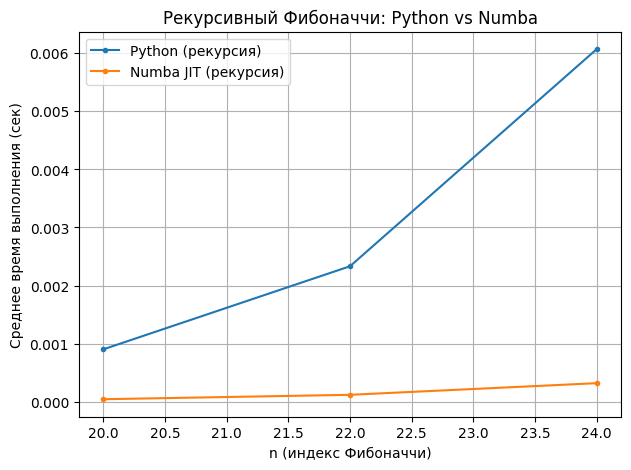

In [ ]:
xs = sorted(py_means.keys())
py_vals  = [py_means[n]  for n in xs]
jit_vals = [jit_means[n] for n in xs]

plt.figure(figsize=(7, 5))
plt.plot(xs, py_vals,  marker='.', label="Python (рекурсия)")
plt.plot(xs, jit_vals, marker='.', label="Numba JIT (рекурсия)")
plt.xlabel("n (индекс Фибоначчи)")
plt.ylabel("Среднее время выполнения (сек)")
plt.title("Рекурсивный Фибоначчи: Python vs Numba")
plt.legend()
plt.grid(True)
plt.show()


JIT выполняется быстрее потому что она оптимизирууется на уровне ассемблера, как компилируемая. А стандартная функция включает в себя все стандартные проверки python.

## Битва 2

<img style="width:80%" src="https://i.redd.it/0yb3pkyuvrja1.jpg">

Теперь попробуйте придумать кейс, когда можно использовать параметр `cache = True`. Аналогично проведите серию экспериментов и постройте график.

Объясните, почему вы получили такие результаты.

In [ ]:
%%ipytest
import pytest
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

@jit(nopython=True, cache=False)
def no_cache_fib(n):
    if n <= 1:
        return n
    return jit_fib(n - 1) + jit_fib(n - 2)

@jit(nopython=True, cache=True)
def cache_fib(n):
    if n <= 1:
        return n
    return jit_fib(n - 1) + jit_fib(n - 2)

sizes = [1_000, 5_000, 10_000, 20_000, 50_000]

no_cache_means = {}
cache_means = {}

@pytest.mark.parametrize("n", sizes)
def test_no_cache_speed(benchmark, n):
    no_cache_fib(10)
    benchmark(no_cache_fib, n)
    no_cache_means[n] = benchmark.stats['mean']

@pytest.mark.parametrize("n", sizes)
def test_cache_speed(benchmark, n):
    cache_fib(10)
    benchmark(cache_fib, n)
    cache_means[n] = benchmark.stats['mean']



RuntimeError: cannot cache function 'cache_fib': no locator available for file '/tmp/ipython-input-3641858112.py'


no tests ran in 0.00s


In [ ]:
xs = sorted(no_cache_means.keys())
nc_vals = [no_cache_means[n] for n in xs]
c_vals  = [cache_means[n]   for n in xs]

plt.figure(figsize=(7, 5))
plt.plot(xs, nc_vals, marker='.', label="cache=False")
plt.plot(xs, c_vals,  marker='.', label="cache=True")
plt.xlabel("n (число итераций)")
plt.ylabel("Среднее время выполнения (сек)")
plt.title("Кеширование Numba при вычислении чисел Фибоначчи")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'no_cache_means' is not defined

In [ ]:
С кэшированием выполняется быстрее так как не высчитываются заново значения в рекурсии.

## Битва 3

<img style="width:50%" src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQhlxWPBBaAbhESuV1eTykOApE6NPPnPW348X4vozn_upE3XC5oEZri3MCjo4rmK-JREEg&usqp=CAU">

Последнее, что мы проверим -- параметр `parallel = True`. Сравните его с чистым питоном, а также с `@jit` без этой опции.
Постройте графики и дайте пояснения полученным результатам.

In [ ]:
%%ipytest
import pytest
import numpy as np
from numba import jit, prange
import matplotlib.pyplot as plt

def py_sum_squares(a: np.ndarray) -> float:
    total = 0.0
    for x in a:
        total += x * x
    return total

@jit(nopython=True)
def numba_sum_squares(a: np.ndarray) -> float:
    total = 0.0
    for x in a:
        total += x * x
    return total

@jit(nopython=True, parallel=True)
def numba_parallel_sum_squares(a: np.ndarray) -> float:
    total = 0.0
    for i in prange(a.size):
        total += a[i] * a[i]
    return total

sizes = [50_000, 100_000, 200_000, 500_000, 1_000_000]

times_py = {}
times_numba = {}
times_parallel = {}

@pytest.mark.parametrize("n", sizes)
def test_python_speed(benchmark, n):
    a = np.arange(n, dtype=np.float64)
    benchmark(py_sum_squares, a)
    times_py[n] = benchmark.stats['mean']

@pytest.mark.parametrize("n", sizes)
def test_numba_speed(benchmark, n):
    a = np.arange(n, dtype=np.float64)
    numba_sum_squares(a[:10])
    benchmark(numba_sum_squares, a)
    times_numba[n] = benchmark.stats['mean']

@pytest.mark.parametrize("n", sizes)
def test_numba_parallel_speed(benchmark, n):
    a = np.arange(n, dtype=np.float64)
    numba_parallel_sum_squares(a[:10])
    benchmark(numba_parallel_sum_squares, a)
    times_parallel[n] = benchmark.stats['mean']



...............                                                                              [100%]

-------------------------------------------------------------------------------------------------------- benchmark: 15 tests ---------------------------------------------------------------------------------------------------------
Name (time in us)                               Min                     Max                    Mean                StdDev                  Median                   IQR            Outliers          OPS            Rounds  Iterations
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
test_numba_parallel_speed[50000]            27.4200 (1.0)        1,882.2000 (5.42)          56.3751 (1.17)       131.4364 (19.63)         29.5245 (1.0)         23.7700 (169.79)    203;253  17,738.3277 (0.85

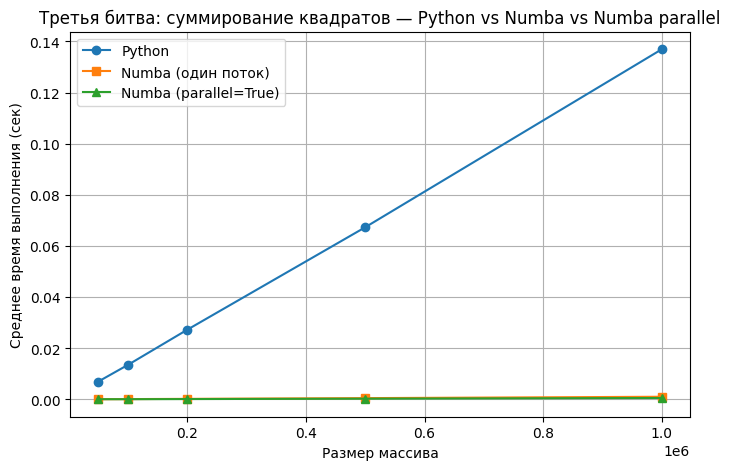

In [ ]:
xs = sorted(times_py.keys())
py_vals = [times_py[n] for n in xs]
numba_vals = [times_numba[n] for n in xs]
parallel_vals = [times_parallel[n] for n in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, py_vals, marker='o', label="Python")
plt.plot(xs, numba_vals, marker='s', label="Numba (один поток)")
plt.plot(xs, parallel_vals, marker='^', label="Numba (parallel=True)")
plt.xlabel("Размер массива")
plt.ylabel("Среднее время выполнения (сек)")
plt.title("Третья битва: суммирование квадратов — Python vs Numba vs Numba parallel")
plt.legend()
plt.grid(True)
plt.show()

# Параллельные вселенные (БОНУСНОЕ за 3 балла)

<img style="width:80%" src="https://upload.wikimedia.org/wikipedia/ru/2/2c/The_Farnsworth_Parabox.jpg">

Как вам известно, работа -- это интеграл силы по пути.
$$
    A = \int_a^b F(x) dx
$$

В этот раз Planet Express необходимо выполнить уникальную задачу: доставить кусочек жаренного баггало каждому жителю ко дню свободы. Для этого они решили воспользоваться помощью других экипажей из параллельных вселенных. Однако, Хермес не может позволить компании разориться. Помогите ему найти оптимальное число команд.

Сила экипажа -- это $F(x) = x$. Путь же предстоит от Земли до Омикрон Персей 8, до которой лететь целых 1000 световых лет. Так как силы каждой команды равны, то разбейте весь пусть на равные по длине подотрезки и подсчитайте интеграл на каждом из них. Далее сложите полученные результаты.

Для вычисления интеграла используйте любой из методов:
- метод парабол
- метод прямоугольников
- метод трапеций

Ниже реализуйте функцию подсчета интеграла:

In [ ]:
import math

def integral(left: float, right: float, fun: Callable[[float], float]) -> float:
    n = 100_000
    width = (right - left) / n
    total = 0.0
    for i in range(n):
        x = left + (i + 0.5) * width
        total += fun(x)
    return total * width


In [ ]:
assert abs(integral(0, 10, lambda x: x) - 50) < 1e-3
assert abs(integral(0, 30, lambda x: x ** 2) - 9000) < 0.1
assert abs(integral(-pi / 7, pi / 7, sin)) < 1e-3
assert abs(integral(2.2, 4.4, exp) - 72.425855) < 1e-3

Теперь перейдем к поиску оптимального числа команда. Так как питон не поддерживает многопоточку (новые версии не рассматриваем), то единственный способ использовать параллельность в нем -- это `os.fork`. Для общения же между процессами будем использовать `os.pipe` -- специальный инструмент однонаправленного межпроцессного взаимодействия.

Напишите функцию, которая принимает количество дополнительных процессов и распараллеливает подсчет на заданное число. Такая функция должна выдавать общую скорость работы. Более подробно, функция запускает $N$ подпроцессов через `os.fork`, каждый из них подсчитывает значение интеграла на своем подотрезке, после чего возвращает результат через пайп главному процессу и завершает работу. Главный же процесс суммирует полученные результаты и завершает работу.

In [ ]:
import os
import struct

def parallel_integral(num_procs: int, left: float, right: float, fun: Callable[[float], float]) -> float:
    parts = num_procs + 1
    step = (right - left) / parts
    results = []
    pipes = []
    pids = []
    for i in range(num_procs):
        r, w = os.pipe()
        pid = os.fork()
        if pid == 0:
            os.close(r)
            local_left = left + i * step
            local_right = local_left + step
            res = integral(local_left, local_right, fun)
            os.write(w, struct.pack('d', res))
            os.close(w)
            os._exit(0)
        else:
            os.close(w)
            pipes.append(r)
            pids.append(pid)
    res_parent = integral(left + num_procs * step, right, fun)
    for r in pipes:
        data = os.read(r, 8)
        if data:
            results.append(struct.unpack('d', data)[0])
        os.close(r)
    for pid in pids:
        os.waitpid(pid, 0)
    return res_parent + sum(results)

Запустите функцию выше для разного числа процессов. Постройте график ускорения ($E = \frac{\tau_{1 proc}}{\tau_{N proc}}$). Используйте `matplotlib` для этого: подпишите оси, укажите единицы измерения, добавьте легенду и шкалу.

In [ ]:
left, right = 0.0, 10.0

def f(x):
    return x

t_start = time.perf_counter()
base_val = integral(left, right, f)
base_time = time.perf_counter() - t_start
procs = [0, 1, 2, 3, 4]
times = []
speedup = []
for p in procs:
    st = time.perf_counter()
    parallel_integral(p, left, right, f)
    t = time.perf_counter() - st
    times.append(t)
    speedup.append(base_time / t)
plt.figure()
plt.plot([p + 1 for p in procs], speedup)
plt.xlabel('Количество процессов (включая основной)')
plt.ylabel('Ускорение')
plt.title('Ускорение параллельного интегрирования')
plt.grid(True)
plt.show()


Как полученные вами результаты соотносятся с законом Амдала?

Сколько в итоге команд нужно нанять профессору Фарнсворту?

При ответе обязательно укажите параметры процессора:
* На каком вы процессоре запускаете
* Сколько ядер в процессоре (сколько эффективных и сколько производительных)

Если у вас на тачке мало потоков (меньше 10), _не путать с ядрами_, то в коллабе можно выбрать рантайм `v5e-1 TPU` и поиграться с большим числом потоков в системе.

Почему так важно знать число ядер и потоков в процессоре для параллельных вычислений?


<b><font color="#FF69B4"> Ваш ответ здесь </font></b>